## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    augmentation = False
    augmentation_weights = [0.9, 0.1]
    proportion_of_augmented = 0.25

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [90]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/',
                'Konstytucja' : '../models/Konstytucja/'}

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) ocena jakości

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [7]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [8]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

In [9]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.007888040712468193

In [12]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [13]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Data augmentation

In [14]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [15]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))

    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']

    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [16]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    X_augmented = np.array(X_y_augmented[columns_to_keep_inds[object_name]].values)
    y_augmented = np.array(X_y_augmented[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [17]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [18]:
if preprocessing_method == 'normalization':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)

/tmp/ipykernel_4636/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


### Converting to tensors

In [19]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [20]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
    
else:
    
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [21]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [22]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [23]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [24]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [25]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [26]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [27]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [28]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [29]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.3934638996918998 test 3.3453267010358663
EPOCH 2:
LOSS train 3.370290368795395 test 3.3228617903513786
EPOCH 3:
LOSS train 3.3492611845334372 test 3.299721180704924
EPOCH 4:
LOSS train 3.325786203145981 test 3.2760533375617786
EPOCH 5:
LOSS train 3.300280491511027 test 3.2517909029355416
EPOCH 6:
LOSS train 3.2768337428569794 test 3.2258481308435782
EPOCH 7:
LOSS train 3.2471137245496116 test 3.1983037371666003
EPOCH 8:
LOSS train 3.218384434779485 test 3.168847083663329
EPOCH 9:
LOSS train 3.1839330991109214 test 3.137173269880124
EPOCH 10:
LOSS train 3.156490663687388 test 3.103474120604686
EPOCH 11:
LOSS train 3.113819827636083 test 3.0674679652238503
EPOCH 12:
LOSS train 3.0808636943499246 test 3.0300112064068134
EPOCH 13:
LOSS train 3.045763611793518 test 2.990776779483526
EPOCH 14:
LOSS train 3.00261719028155 test 2.949158357656919
EPOCH 15:
LOSS train 2.957926591237386 test 2.9054030890648184
EPOCH 16:
LOSS train 2.914640247821808 test 2.8595379256285156
EP

LOSS train 1.1679811129967372 test 1.1615903560931866
EPOCH 132:
LOSS train 1.169312094648679 test 1.1608133844076058
EPOCH 133:
LOSS train 1.1718797435363133 test 1.1599481301812025
EPOCH 134:
LOSS train 1.1588147108753521 test 1.1590639946552423
EPOCH 135:
LOSS train 1.16219508399566 test 1.1582951808205018
EPOCH 136:
LOSS train 1.1616052985191345 test 1.1573721661781653
EPOCH 137:
LOSS train 1.1596477876106899 test 1.1563942931783504
EPOCH 138:
LOSS train 1.162388453880946 test 1.155522168561434
EPOCH 139:
LOSS train 1.1596066157023113 test 1.1546161666512489
EPOCH 140:
LOSS train 1.157176713148753 test 1.1536567554641992
EPOCH 141:
LOSS train 1.1628468086322148 test 1.1530139442055654
EPOCH 142:
LOSS train 1.1609251946210861 test 1.1519800984324553
EPOCH 143:
LOSS train 1.1599267174800236 test 1.151012441668755
EPOCH 144:
LOSS train 1.157701537013054 test 1.150079836639074
EPOCH 145:
LOSS train 1.1564329713582993 test 1.149185903255756
EPOCH 146:
LOSS train 1.1578347583611805 test 

LOSS train 1.0896858101089795 test 1.0794095755005495
EPOCH 261:
LOSS train 1.0915650526682537 test 1.0793852475973276
EPOCH 262:
LOSS train 1.0918241639931996 test 1.0787718419272165
EPOCH 263:
LOSS train 1.092615154882272 test 1.0786487817573243
EPOCH 264:
LOSS train 1.092749093969663 test 1.0782051526010037
EPOCH 265:
LOSS train 1.0905817796786625 test 1.077538825972722
EPOCH 266:
LOSS train 1.087137222290039 test 1.0773042554656664
EPOCH 267:
LOSS train 1.087984209259351 test 1.0769175803050017
EPOCH 268:
LOSS train 1.0877379725376766 test 1.0766667835987531
EPOCH 269:
LOSS train 1.0883813699086506 test 1.0761201476439453
EPOCH 270:
LOSS train 1.0882226054867108 test 1.0756636013205234
EPOCH 271:
LOSS train 1.0880571429928143 test 1.07547340249786
EPOCH 272:
LOSS train 1.0848698591192563 test 1.0748383491849287
EPOCH 273:
LOSS train 1.08315060287714 test 1.0746930681742155
EPOCH 274:
LOSS train 1.089801862835884 test 1.0743341088486023
EPOCH 275:
LOSS train 1.0837333500385284 test 

LOSS train 1.0250506425897281 test 1.0106231141166808
EPOCH 389:
LOSS train 1.0264835730195045 test 1.0101305593091707
EPOCH 390:
LOSS train 1.0228372514247894 test 1.009320967625349
EPOCH 391:
LOSS train 1.0226957127451897 test 1.0084489369812684
EPOCH 392:
LOSS train 1.0229283720254898 test 1.0079146182880951
EPOCH 393:
LOSS train 1.0201695561408997 test 1.0072791800476038
EPOCH 394:
LOSS train 1.0192644794782002 test 1.0065385217658984
EPOCH 395:
LOSS train 1.0181796302398045 test 1.0059260427569732
EPOCH 396:
LOSS train 1.0198550919691722 test 1.0050145040146816
EPOCH 397:
LOSS train 1.0117468933264415 test 1.0043802893123566
EPOCH 398:
LOSS train 1.0162249778707821 test 1.0037633020526324
EPOCH 399:
LOSS train 1.0160474653045337 test 1.003077036046829
EPOCH 400:
LOSS train 1.0145769814650218 test 1.0025995503442409
EPOCH 401:
LOSS train 1.0103532051046689 test 1.001719647206557
EPOCH 402:
LOSS train 1.0140058274070423 test 1.0011795056936068
EPOCH 403:
LOSS train 1.01102198412021 

LOSS train 0.9660694549481074 test 0.9519436170466435
EPOCH 517:
LOSS train 0.9633936161796252 test 0.9514485610028108
EPOCH 518:
LOSS train 0.9622874210278193 test 0.9512528947721689
EPOCH 519:
LOSS train 0.964818517367045 test 0.9510354264042317
EPOCH 520:
LOSS train 0.9663907264669737 test 0.9507452788070226
EPOCH 521:
LOSS train 0.9619034826755524 test 0.9506142534315586
EPOCH 522:
LOSS train 0.9688223749399185 test 0.9501554431441502
EPOCH 523:
LOSS train 0.9647615924477577 test 0.9501858811538954
EPOCH 524:
LOSS train 0.9674549177289009 test 0.9497299022017381
EPOCH 525:
LOSS train 0.9666566749413809 test 0.9496955329026932
EPOCH 526:
LOSS train 0.9592265064517657 test 0.9493588645870868
EPOCH 527:
LOSS train 0.9650811776518822 test 0.9494232828800495
EPOCH 528:
LOSS train 0.9640846227606138 test 0.9488635041965888
EPOCH 529:
LOSS train 0.9652431532740593 test 0.9489573618158316
EPOCH 530:
LOSS train 0.9609292671084404 test 0.9486161065407288
EPOCH 531:
LOSS train 0.9622167895237

...

LOSS train 0.7257692789038023 test 0.7317430638541014
EPOCH 4425:
LOSS train 0.7260609542330106 test 0.7316368059470103
EPOCH 4426:
LOSS train 0.7271903281410536 test 0.7312812257080507
EPOCH 4427:
LOSS train 0.7282824019591013 test 0.7316670758028825
EPOCH 4428:
LOSS train 0.7241526991128922 test 0.731594188282123
EPOCH 4429:
LOSS train 0.7265173867344856 test 0.7315759729880553
EPOCH 4430:
LOSS train 0.7285971691211065 test 0.7316694175967804
EPOCH 4431:
LOSS train 0.728166344265143 test 0.7316308361406509
EPOCH 4432:
LOSS train 0.725312074025472 test 0.7316189038256804
EPOCH 4433:
LOSS train 0.7267537415027618 test 0.7314119288554558
EPOCH 4434:
LOSS train 0.7279536550243696 test 0.7316009086676133
EPOCH 4435:
LOSS train 0.7271256869037946 test 0.7321161906879682
EPOCH 4436:
LOSS train 0.727441298464934 test 0.7314877910491747
EPOCH 4437:
LOSS train 0.7294145176808039 test 0.7314775511431388
EPOCH 4438:
LOSS train 0.7293578485647837 test 0.7312936534866309
EPOCH 4439:
LOSS train 0.7

LOSS train 0.7258856346209844 test 0.7304294483019755
EPOCH 4551:
LOSS train 0.7251418580611547 test 0.7302902707495751
EPOCH 4552:
LOSS train 0.723855771124363 test 0.7303535472315091
EPOCH 4553:
LOSS train 0.7273214012384415 test 0.7303370086810528
EPOCH 4554:
LOSS train 0.7262726873159409 test 0.7303324855099886
EPOCH 4555:
LOSS train 0.7255222499370575 test 0.7299971162890777
EPOCH 4556:
LOSS train 0.7252708002924919 test 0.7305365569698505
EPOCH 4557:
LOSS train 0.7279329150915146 test 0.7299187022906083
EPOCH 4558:
LOSS train 0.7271163513263067 test 0.7305355936097793
EPOCH 4559:
LOSS train 0.7254165386160215 test 0.7300160681399015
EPOCH 4560:
LOSS train 0.7242719779411951 test 0.7299072530980294
EPOCH 4561:
LOSS train 0.7256229495008787 test 0.7299902465289984
EPOCH 4562:
LOSS train 0.7270836383104324 test 0.7303609617818625
EPOCH 4563:
LOSS train 0.7276910518606504 test 0.7304550010615435
EPOCH 4564:
LOSS train 0.7248759940266609 test 0.7303737463859411
EPOCH 4565:
LOSS train 

LOSS train 0.7240616406003634 test 0.729142657151589
EPOCH 4677:
LOSS train 0.7234190354744593 test 0.7290721125327624
EPOCH 4678:
LOSS train 0.724450575808684 test 0.7294078156734124
EPOCH 4679:
LOSS train 0.724229154487451 test 0.7289757081331351
EPOCH 4680:
LOSS train 0.7252440030376116 test 0.7289995095668695
EPOCH 4681:
LOSS train 0.7257726912697157 test 0.7288553179838718
EPOCH 4682:
LOSS train 0.721835657954216 test 0.7290974776332195
EPOCH 4683:
LOSS train 0.7256243427594503 test 0.728637059739767
EPOCH 4684:
LOSS train 0.7216702923178673 test 0.7286491385637186
EPOCH 4685:
LOSS train 0.7260287205378214 test 0.7287378334846252
EPOCH 4686:
LOSS train 0.7243390356500944 test 0.7291246253710527
EPOCH 4687:
LOSS train 0.725581889351209 test 0.7286511307534499
EPOCH 4688:
LOSS train 0.7237530052661896 test 0.7288514299843556
EPOCH 4689:
LOSS train 0.7238442848126093 test 0.7286698706257038
EPOCH 4690:
LOSS train 0.7237651546796163 test 0.7289005852089478
EPOCH 4691:
LOSS train 0.724

LOSS train 0.727161151667436 test 0.7278079344676092
EPOCH 4802:
LOSS train 0.7214867547154427 test 0.7276003564397494
EPOCH 4803:
LOSS train 0.7223558699091276 test 0.7274352624821357
EPOCH 4804:
LOSS train 0.7224272092183431 test 0.7276131340135367
EPOCH 4805:
LOSS train 0.7222476899623871 test 0.7273539336828085
EPOCH 4806:
LOSS train 0.7250186329086622 test 0.7276840944129687
EPOCH 4807:
LOSS train 0.7258886024355888 test 0.7274379481680883
EPOCH 4808:
LOSS train 0.7228756844997406 test 0.7277758709704265
EPOCH 4809:
LOSS train 0.7220074410239855 test 0.7277773319337613
EPOCH 4810:
LOSS train 0.7200990145405134 test 0.7275175373141582
EPOCH 4811:
LOSS train 0.7230802997946739 test 0.72771578843777
EPOCH 4812:
LOSS train 0.7233568032582601 test 0.7275809029929149
EPOCH 4813:
LOSS train 0.7219937046368917 test 0.7274869694350622
EPOCH 4814:
LOSS train 0.7217165182034174 test 0.7276186171250466
EPOCH 4815:
LOSS train 0.7226706743240356 test 0.7273828307405497
EPOCH 4816:
LOSS train 0.

LOSS train 0.7204572831590971 test 0.726142786252193
EPOCH 4928:
LOSS train 0.722183865805467 test 0.7260666515773687
EPOCH 4929:
LOSS train 0.7197494730353355 test 0.7267143659102611
EPOCH 4930:
LOSS train 0.7192271600166956 test 0.7261338900106076
EPOCH 4931:
LOSS train 0.7216928402582804 test 0.7267264523567297
EPOCH 4932:
LOSS train 0.7211758370200793 test 0.7262573932799009
EPOCH 4933:
LOSS train 0.7201318914691607 test 0.7262626936038336
EPOCH 4934:
LOSS train 0.7190673922499021 test 0.7257716174882192
EPOCH 4935:
LOSS train 0.7215826362371445 test 0.7264282218156717
EPOCH 4936:
LOSS train 0.7183174341917038 test 0.7261956519041306
EPOCH 4937:
LOSS train 0.7220752760767937 test 0.7261687084459342
EPOCH 4938:
LOSS train 0.7195911034941673 test 0.726062642935759
EPOCH 4939:
LOSS train 0.7205193514625231 test 0.7258876411005473
EPOCH 4940:
LOSS train 0.7201334064205488 test 0.7263794991450432
EPOCH 4941:
LOSS train 0.7214094723264376 test 0.7261928868408386
EPOCH 4942:
LOSS train 0.

In [ ]:
import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path[object_name]+'model_'+now)

In [30]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [31]:
%matplotlib notebook

<IPython.core.display.Javascript object>


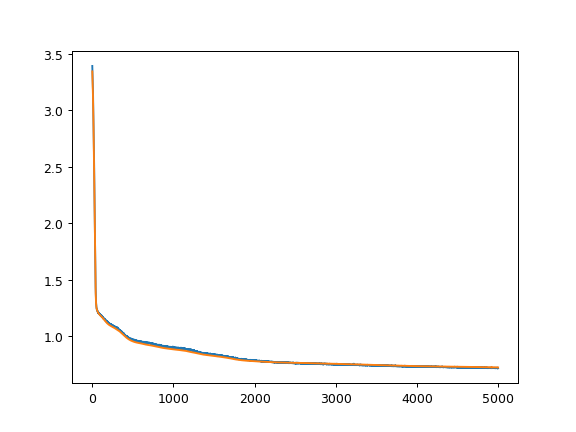

In [34]:
#Documents
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

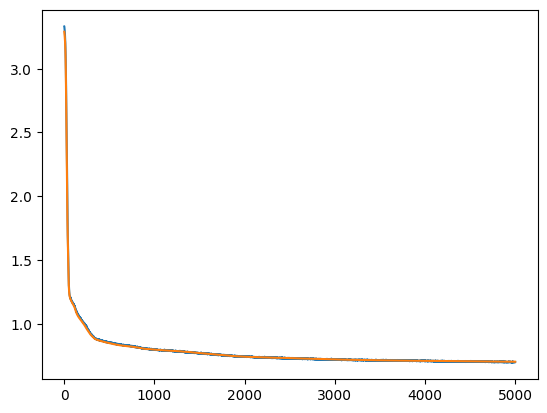

In [30]:
#Documents
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

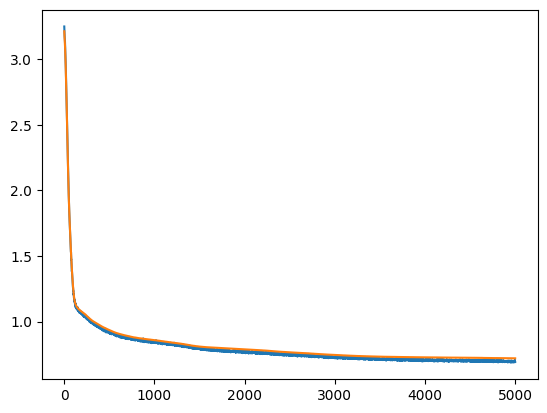

In [31]:
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

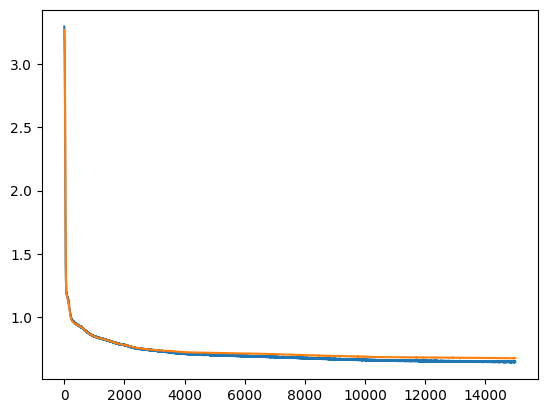

In [35]:
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

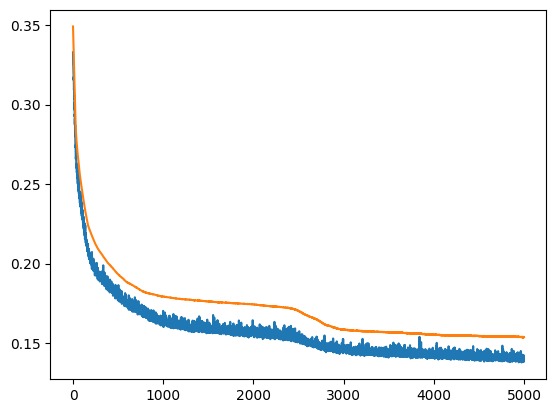

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights 1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

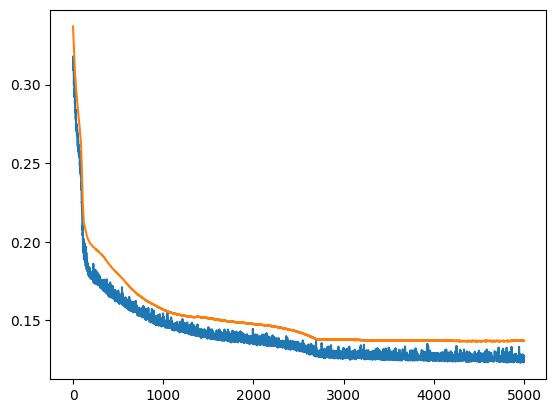

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

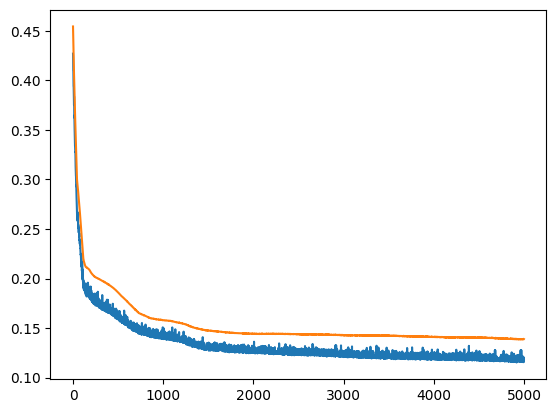

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

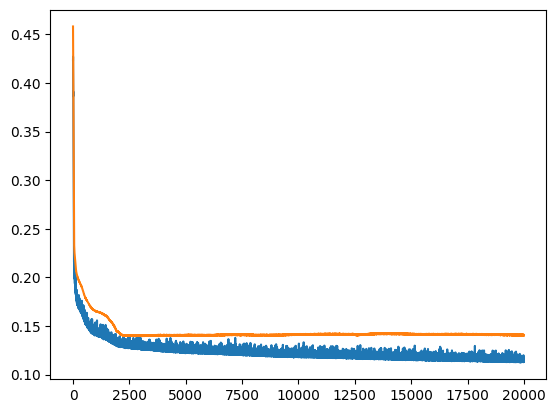

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

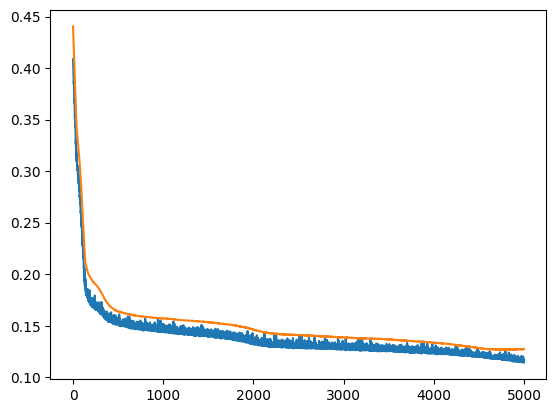

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Prediction on test set

In [35]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [36]:
lab

tensor([[ 0.6814, -3.8429, -7.3168,  ..., -2.0901, -5.5168, -0.8327],
        [ 1.7116, -4.4546, -7.4808,  ..., -1.2107, -5.7975, -1.4870],
        [ 1.7433, -3.2536, -7.8672,  ..., -4.1254, -3.4859, -2.4003],
        ...,
        [ 1.5180, -2.1008, -6.8141,  ..., -3.6722, -4.1360,  0.2913],
        [-0.0894, -3.8682, -7.6653,  ..., -1.7766, -5.5490, -0.9989],
        [-0.3599, -5.9045, -7.8310,  ...,  1.1395, -2.5659, -0.6577]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [37]:
out

tensor([[-0.0707, -3.3548, -7.4794,  ..., -1.8838, -6.0202, -1.4762],
        [ 1.2943, -3.8369, -7.6114,  ..., -1.1684, -3.8772, -1.0793],
        [ 1.4126, -3.2247, -8.0946,  ..., -3.9518, -3.5859, -2.7821],
        ...,
        [ 0.2171, -3.5426, -7.7367,  ..., -3.6456, -3.9435,  0.2989],
        [-0.1893, -3.6629, -8.2343,  ..., -1.8908, -5.8795, -1.9618],
        [ 0.2202, -4.0561, -8.5498,  ...,  1.0719, -4.2072, -0.2817]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [38]:
res

tensor([[0.7521, 0.4881, 0.1626,  ..., 0.2062, 0.5033, 0.6435],
        [0.4173, 0.6177, 0.1305,  ..., 0.0423, 1.9203, 0.4077],
        [0.3307, 0.0290, 0.2273,  ..., 0.1736, 0.1001, 0.3819],
        ...,
        [1.3009, 1.4418, 0.9226,  ..., 0.0266, 0.1925, 0.0076],
        [0.0999, 0.2053, 0.5690,  ..., 0.1142, 0.3306, 0.9629],
        [0.5801, 1.8484, 0.7188,  ..., 0.0677, 1.6413, 0.3760]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [39]:
torch.mean(res, axis=0) 

tensor([0.6568, 0.6850, 0.9210, 0.6376, 0.7400, 0.6831, 0.8186, 0.7010],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [40]:
torch.mean(res)

tensor(0.7304, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [91]:
import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path[object_name]+'model_regression_'+now)

### Visualisations

In [57]:
dim_nr = 7
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

<IPython.core.display.Javascript object>


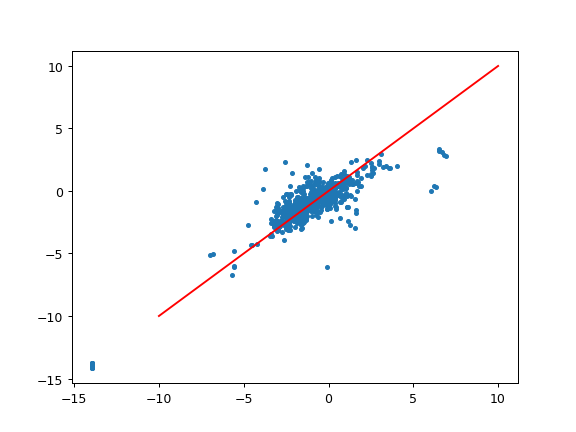

In [58]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [59]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [60]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [61]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_4636/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4636/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_4636/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [62]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [63]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [64]:
len(closest)

780

In [65]:
y_test_df['Closest'] = closest

In [66]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

724

In [67]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9282051282051282

#### Now let's check if it works for the neural network's output.

In [68]:
model.eval()
outputs = model(X_test)

In [69]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [70]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [71]:
len(closest)

780

In [72]:
outputs_df['Closest'] = closest

In [73]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

120

In [74]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.15384615384615385

## Quality of prediction: confidence intervals

In [75]:
model.eval()
outputs = model(X_test)

In [76]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [77]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [78]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_4636/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_4636/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_4636/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [79]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_4636/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4636/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_4636/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [80]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [81]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [82]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [83]:
np.array(sd_res_list).mean()

0.32387820512820514

On consecutive coordinates:

In [84]:
np.array(sd_res_list).mean(0)

array([[0.42051282, 0.35769231, 0.47948718, 0.22051282, 0.21410256,
        0.3       , 0.2525641 , 0.34615385]])

Percentage of points inside min-max interval:

In [85]:
np.array(min_max_res_list).mean()

0.26282051282051283

On consecutive coordinates:

In [86]:
np.array(min_max_res_list).mean(0)

array([[0.32948718, 0.29615385, 0.40384615, 0.17051282, 0.17179487,
        0.24358974, 0.20641026, 0.28076923]])

### Visualisations of mean +- 2 * standard deviation intervals

<IPython.core.display.Javascript object>


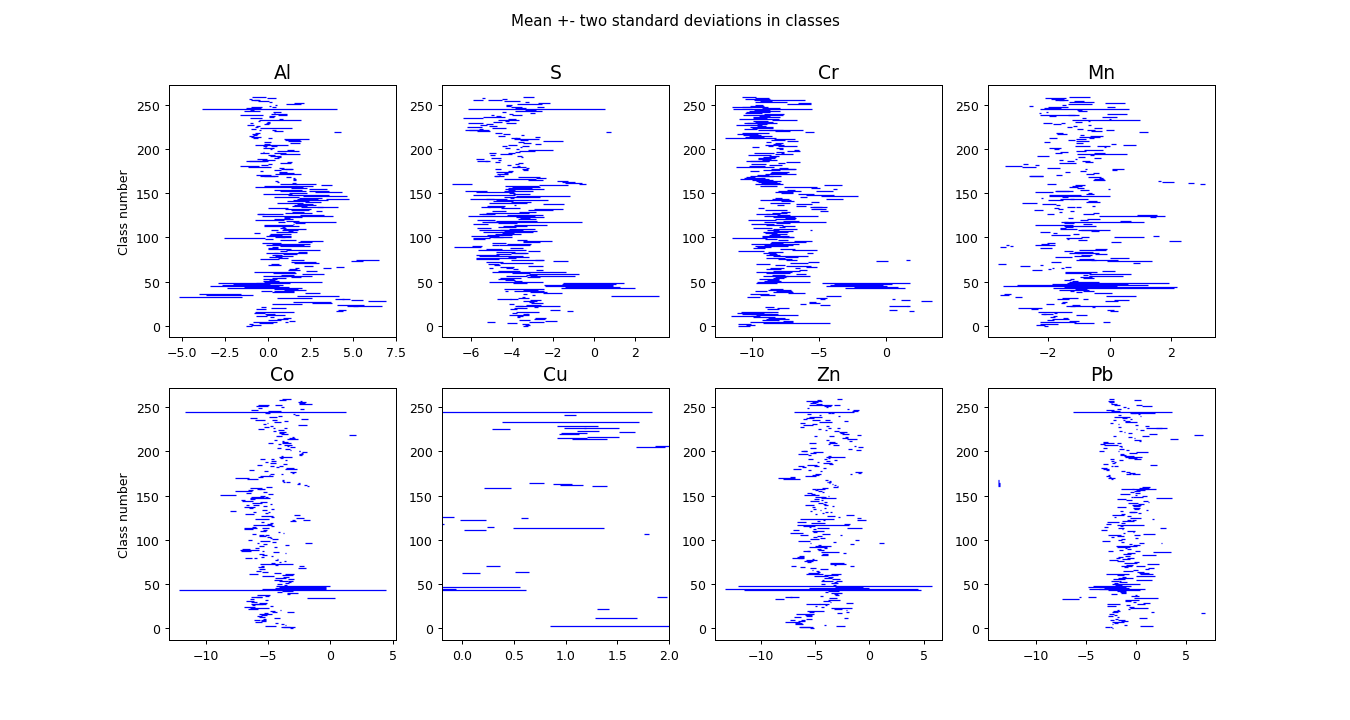

In [87]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

### Visualisations of min-max intervals

<IPython.core.display.Javascript object>


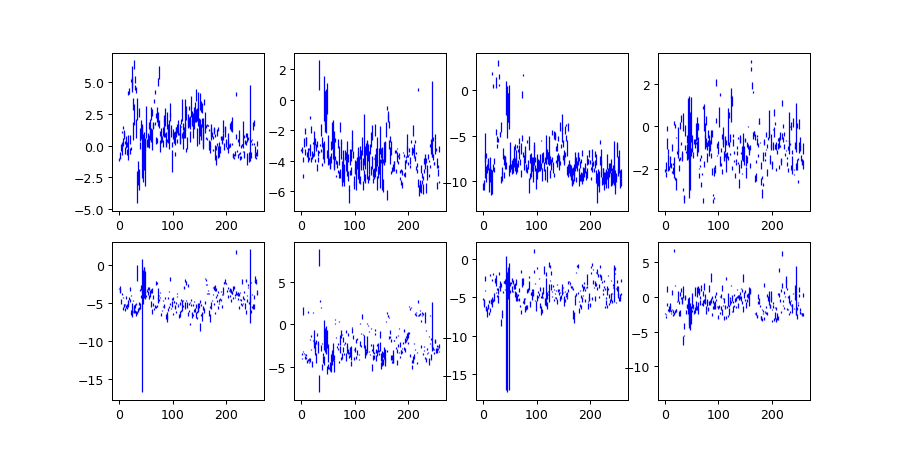

In [88]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

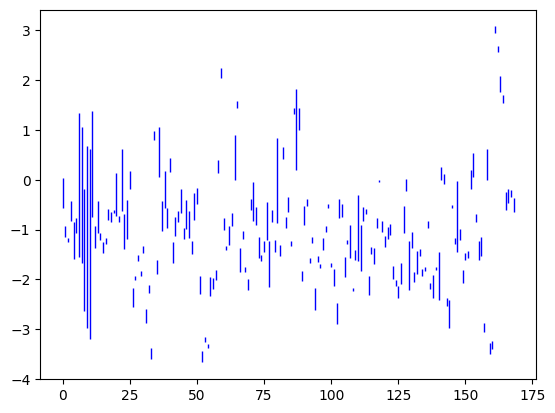

In [69]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

## Prediction on the real dataset (without ground truth)

In [ ]:
object_name == 'Konstytucja'

In [ ]:
target_df = pd.ExcelFile(data_path[object_name])
target_df = target_df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(0, 3945))
target_df.columns = target_df.parse('Arkusz1', header=None, usecols=range(32,59), nrows=1).values[0]

In [ ]:
target_df = target_df.reset_index(drop=False)

In [ ]:
target_df['Sample_id'] = np.repeat(range(int(target_df.shape[0]/15)), 15, axis=0)

In [ ]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

In [ ]:
target_df = target_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

In [ ]:
(target_df.shape[0] - target_df.dropna().shape[0])/target_df.shape[0]

In [ ]:
target_df.dropna(inplace=True)

## Interpretability